In [1]:
!pip install flask pandas numpy scikit-learn pyngrok -q

In [3]:
from google.colab import files

uploaded = files.upload()

Saving movies_dataset(1).csv to movies_dataset(1).csv


In [4]:
!pip install flask pyngrok scikit-learn pandas numpy matplotlib seaborn -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import os

In [6]:
df = pd.read_csv("movies_dataset(1).csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (1500, 11)


,movie_id,budget,genre,release_season,runtime,cast_popularity,director_experience,critic_score,audience_score,marketing_spend,revenue
0,1,26645143.96,Animation,Summer,97.7,31.04,3,92.12,91.33,10729988.02,2.749315e+08
1,2,15013254.61,Sci-Fi,Summer,101.4,44.36,6,58.24,68.24,4619199.18,2.081661e+08
2,3,34522156.66,Comedy,Spring,88.0,77.60,5,65.60,65.06,15355443.93,1.772409e+08
3,4,4828305.44,Horror,Summer,78.3,70.47,5,51.93,63.91,1956200.06,1.417941e+08
4,5,5465855.99,Animation,Summer,107.8,84.38,9,43.14,46.34,1205777.24,1.620987e+08


In [7]:
print("Column Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Column Names:
['movie_id', 'budget', 'genre', 'release_season', 'runtime', 'cast_popularity', 'director_experience', 'critic_score', 'audience_score', 'marketing_spend', 'revenue']

Missing Values:
movie_id                0
budget                  0
genre                   0
release_season          0
runtime                45
cast_popularity         0
director_experience     0
critic_score           45
audience_score         45
marketing_spend         0
revenue                 0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   movie_id             1500 non-null   int64  
 1   budget               1500 non-null   float64
 2   genre                1500 non-null   object 
 3   release_season       1500 non-null   object 
 4   runtime              1455 non-null   float64
 5   cast_popularity    

In [8]:
df = df.drop(columns=["movie_id"])

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1500, 10)


In [9]:
# Numerical columns
numeric_columns = [
    "budget",
    "runtime",
    "cast_popularity",
    "director_experience",
    "critic_score",
    "audience_score",
    "marketing_spend",
    "revenue"
]

# Fill numerical missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


# Categorical columns
categorical_columns = [
    "genre",
    "release_season"
]

# Fill categorical missing values with mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
budget                 0
genre                  0
release_season         0
runtime                0
cast_popularity        0
director_experience    0
critic_score           0
audience_score         0
marketing_spend        0
revenue                0
dtype: int64


In [10]:
X = df.drop(columns=["revenue"])
y = df["revenue"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print("revenue")

Input Features:
['budget', 'genre', 'release_season', 'runtime', 'cast_popularity', 'director_experience', 'critic_score', 'audience_score', 'marketing_spend']

Target:
revenue


In [11]:
numeric_features = [
    "budget",
    "runtime",
    "cast_popularity",
    "director_experience",
    "critic_score",
    "audience_score",
    "marketing_spend"
]

categorical_features = [
    "genre",
    "release_season"
]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [13]:
elastic_net = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("elasticnet", elastic_net)
    ]
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1200
Testing samples: 300


In [15]:
print("Training Elastic Net model...")

model.fit(X_train, y_train)

print("Model training completed successfully!")

Training Elastic Net model...
Model training completed successfully!


In [16]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print(f"MAE  : ${mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

print("======================================")


========== MODEL PERFORMANCE ==========
MAE  : $47,143,413.08
MSE  : 4,843,000,913,382,189.00
RMSE : $69,591,672.73
R²   : 0.7028


In [17]:
results = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": y_pred
})

display(results.head(10))

,Actual Revenue,Predicted Revenue
0,8.328122e+07,6.847805e+07
1,1.706969e+08,1.388557e+08
2,8.441087e+07,1.394452e+08
3,1.148975e+08,1.437829e+08
4,2.949337e+08,2.883631e+08
5,3.278225e+08,2.843652e+08
6,2.112070e+08,2.140981e+08
7,4.906037e+07,8.331615e+07
8,4.299083e+08,2.740570e+08
9,2.680363e+08,2.832523e+08


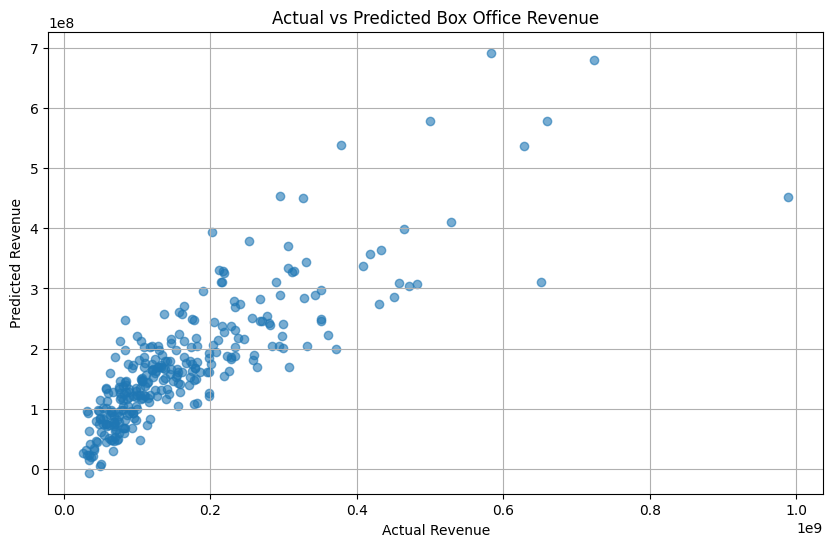

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title(
    "Actual vs Predicted Box Office Revenue"
)

plt.grid(True)

plt.show()

In [19]:
with open("movie_revenue_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved as movie_revenue_model.pkl")

Model saved as movie_revenue_model.pkl


In [20]:
os.makedirs("templates", exist_ok=True)

print("Flask folders created.")

Flask folders created.


In [21]:
app_code = '''

from flask import Flask, render_template, request
import pandas as pd
import pickle

app = Flask(__name__)


# Load trained machine learning model
with open("movie_revenue_model.pkl", "rb") as file:
    model = pickle.load(file)


@app.route("/")
def home():

    return render_template(
        "index.html"
    )


@app.route("/predict", methods=["POST"])
def predict():

    try:

        # Get values from HTML form

        budget = float(
            request.form["budget"]
        )

        genre = request.form["genre"]

        release_season = request.form["release_season"]

        runtime = float(
            request.form["runtime"]
        )

        cast_popularity = float(
            request.form["cast_popularity"]
        )

        director_experience = float(
            request.form["director_experience"]
        )

        critic_score = float(
            request.form["critic_score"]
        )

        audience_score = float(
            request.form["audience_score"]
        )

        marketing_spend = float(
            request.form["marketing_spend"]
        )


        # Create dataframe
        # using the exact dataset feature names

        movie_data = pd.DataFrame({

            "budget": [budget],

            "genre": [genre],

            "release_season": [
                release_season
            ],

            "runtime": [runtime],

            "cast_popularity": [
                cast_popularity
            ],

            "director_experience": [
                director_experience
            ],

            "critic_score": [
                critic_score
            ],

            "audience_score": [
                audience_score
            ],

            "marketing_spend": [
                marketing_spend
            ]

        })


        # Make prediction

        prediction = model.predict(
            movie_data
        )[0]


        # Prevent negative revenue

        prediction = max(
            0,
            prediction
        )


        return render_template(
            "index.html",
            prediction=prediction
        )


    except Exception as e:

        return render_template(
            "index.html",
            error=str(e)
        )


if __name__ == "__main__":

    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False
    )

'''

with open("app.py", "w") as file:
    file.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [22]:
html_code = '''

<!DOCTYPE html>

<html>

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>
        Box Office Revenue Predictor
    </title>


    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
        }


        body {

            font-family:
                Arial,
                Helvetica,
                sans-serif;

            min-height: 100vh;

            background:
                linear-gradient(
                    135deg,
                    #141e30,
                    #243b55
                );

            color: white;

            padding: 30px;

        }


        .container {

            max-width: 1050px;

            margin: auto;

        }


        .header {

            text-align: center;

            margin-bottom: 30px;

        }


        .header h1 {

            font-size: 42px;

            margin-bottom: 10px;

        }


        .header p {

            color: #d6d6d6;

            font-size: 17px;

        }


        .card {

            background:
                rgba(
                    255,
                    255,
                    255,
                    0.10
                );

            backdrop-filter:
                blur(20px);

            border:
                1px solid
                rgba(
                    255,
                    255,
                    255,
                    0.20
                );

            border-radius: 25px;

            padding: 35px;

            box-shadow:
                0 20px 60px
                rgba(
                    0,
                    0,
                    0,
                    0.30
                );

        }


        .section-title {

            font-size: 22px;

            margin-bottom: 25px;

        }


        .grid {

            display: grid;

            grid-template-columns:
                repeat(
                    2,
                    1fr
                );

            gap: 20px;

        }


        .input-group {

            display: flex;

            flex-direction: column;

        }


        label {

            margin-bottom: 8px;

            font-weight: bold;

            font-size: 14px;

        }


        input,
        select {

            width: 100%;

            padding: 14px;

            border-radius: 10px;

            border: none;

            outline: none;

            font-size: 15px;

            background:
                rgba(
                    255,
                    255,
                    255,
                    0.95
                );

            color: #222;

        }


        input:focus,
        select:focus {

            box-shadow:
                0 0 0 3px
                rgba(
                    0,
                    198,
                    255,
                    0.4
                );

        }


        .button-area {

            text-align: center;

            margin-top: 30px;

        }


        button {

            border: none;

            padding:
                15px 45px;

            border-radius: 30px;

            font-size: 17px;

            font-weight: bold;

            color: white;

            cursor: pointer;

            background:
                linear-gradient(
                    90deg,
                    #00c6ff,
                    #0072ff
                );

            transition:
                transform 0.2s;

        }


        button:hover {

            transform:
                translateY(-2px);

        }


        .result {

            margin-top: 30px;

            text-align: center;

            padding: 30px;

            border-radius: 20px;

            background:
                rgba(
                    0,
                    255,
                    150,
                    0.12
                );

            border:
                1px solid
                rgba(
                    0,
                    255,
                    150,
                    0.3
                );

        }


        .result-title {

            font-size: 20px;

            margin-bottom: 10px;

        }


        .amount {

            font-size: 40px;

            font-weight: bold;

            margin: 10px;

            color: #00ffae;

        }


        .result-info {

            color: #d5d5d5;

        }


        .error {

            margin-top: 20px;

            padding: 15px;

            border-radius: 10px;

            background:
                rgba(
                    255,
                    0,
                    0,
                    0.20
                );

            color: #ffdddd;

        }


        .footer {

            text-align: center;

            margin-top: 25px;

            color: #bcbcbc;

            font-size: 13px;

        }


        @media(max-width: 700px) {

            body {

                padding: 15px;

            }


            .grid {

                grid-template-columns:
                    1fr;

            }


            .header h1 {

                font-size: 29px;

            }


            .card {

                padding: 22px;

            }

        }

    </style>

</head>


<body>


<div class="container">


    <div class="header">

        <h1>
            🎬 Box Office Revenue Predictor
        </h1>

        <p>
            Elastic Net Regression Based
            Machine Learning System
        </p>

    </div>


    <div class="card">


        <h2 class="section-title">
            Enter Movie Information
        </h2>


        <form
            action="/predict"
            method="POST"
        >


            <div class="grid">


                <div class="input-group">

                    <label>
                        Production Budget ($)
                    </label>

                    <input
                        type="number"
                        name="budget"
                        step="0.01"
                        min="0"
                        value="50000000"
                        required
                    >

                </div>


                <div class="input-group">

                    <label>
                        Marketing Spend ($)
                    </label>

                    <input
                        type="number"
                        name="marketing_spend"
                        step="0.01"
                        min="0"
                        value="20000000"
                        required
                    >

                </div>


                <div class="input-group">

                    <label>
                        Genre
                    </label>

                    <select name="genre">

                        <option value="Action">
                            Action
                        </option>

                        <option value="Comedy">
                            Comedy
                        </option>

                        <option value="Drama">
                            Drama
                        </option>

                        <option value="Horror">
                            Horror
                        </option>

                        <option value="Romance">
                            Romance
                        </option>

                        <option value="Thriller">
                            Thriller
                        </option>

                    </select>

                </div>


                <div class="input-group">

                    <label>
                        Release Season
                    </label>

                    <select name="release_season">

                        <option value="Spring">
                            Spring
                        </option>

                        <option value="Summer">
                            Summer
                        </option>

                        <option value="Fall">
                            Fall
                        </option>

                        <option value="Winter">
                            Winter
                        </option>

                    </select>

                </div>


                <div class="input-group">

                    <label>
                        Runtime (minutes)
                    </label>

                    <input
                        type="number"
                        name="runtime"
                        step="0.1"
                        min="1"
                        value="120"
                        required
                    >

                </div>


                <div class="input-group">

                    <label>
                        Cast Popularity
                    </label>

                    <input
                        type="number"
                        name="cast_popularity"
                        step="0.01"
                        min="0"
                        value="7"
                        required
                    >

                </div>


                <div class="input-group">

                    <label>
                        Director Experience (years)
                    </label>

                    <input
                        type="number"
                        name="director_experience"
                        min="0"
                        value="10"
                        required
                    >

                </div>


                <div class="input-group">

                    <label>
                        Critic Score
                    </label>

                    <input
                        type="number"
                        name="critic_score"
                        step="0.01"
                        min="0"
                        max="100"
                        value="75"
                        required
                    >

                </div>


                <div class="input-group">

                    <label>
                        Audience Score
                    </label>

                    <input
                        type="number"
                        name="audience_score"
                        step="0.01"
                        min="0"
                        max="100"
                        value="80"
                        required
                    >

                </div>


            </div>


            <div class="button-area">

                <button type="submit">

                    Predict Box Office Revenue

                </button>

            </div>


        </form>


        {% if prediction is defined %}

        <div class="result">

            <div class="result-title">

                🎯 Predicted Box Office Revenue

            </div>


            <div class="amount">

                ${{ "{:,.2f}".format(prediction) }}

            </div>


            <div class="result-info">

                Prediction generated using
                Elastic Net Regression

            </div>

        </div>

        {% endif %}


        {% if error %}

        <div class="error">

            <strong>
                Error:
            </strong>

            {{ error }}

        </div>

        {% endif %}


    </div>


    <div class="footer">

        Machine Learning Project |
        Box Office Revenue Prediction

    </div>


</div>


</body>

</html>

'''

with open(
    "templates/index.html",
    "w"
) as file:

    file.write(html_code)


print("index.html created successfully!")

index.html created successfully!


In [23]:
!ls -l

total 248
-rw-r--r-- 1 root root   2361 Aug 11 18:12  app.py
-rw-r--r-- 1 root root   2906 Aug 11 18:12  movie_revenue_model.pkl
-rw-r--r-- 1 root root 118519 Aug 11 18:06 'movies_dataset(1).csv'
-rw-r--r-- 1 root root 118519 Aug 11 18:04  movies_dataset.csv
drwxr-xr-x 1 root root   4096 Aug 10 13:26  sample_data
drwxr-xr-x 2 root root   4096 Aug 11 18:13  templates


In [24]:
import threading
import time

def run_flask():
    from app import app

    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False
    )

flask_thread = threading.Thread(
    target=run_flask
)

flask_thread.daemon = True

flask_thread.start()

time.sleep(3)

print("Flask server started!")

 * Serving Flask app 'app'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Flask server started!


In [26]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3HmTUDNoImIvjAgfK3pKil8iCEa_2PRKx99EXjCntpSiFYSUR"

ngrok.set_auth_token(
    NGROK_AUTH_TOKEN
)

public_url = ngrok.connect(5000)

print("================================")
print("YOUR FLASK WEBSITE")
print("================================")
print(public_url)

YOUR FLASK WEBSITE
NgrokTunnel: "https://shore-decade-occupant.ngrok-free.dev" -> "http://localhost:5000"
